In [1]:
import torch
import torch.nn as nn
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# Subsampling ratios produced by eigenvector-centrality sampling in train notebook.
# 100 = no subsampling (baseline).
RATIOS = [25, 50, 75, 100]

def train_dir(ratio):
    if ratio == 100:
        return "3ed_trai_h_graphs_hetero_graphs"
    return f"3ed_trai_h_graphs_hetero_sub{ratio}"

# Test graphs are ALWAYS the full set — never subsample the evaluation set.
TEST_DIR = "3ed_tes_h_graphs_hetero_graphs"


Running on: cpu


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GCNConv

class HeteroGAE(nn.Module):
    def __init__(self, hidden_channels=128, out_channels=1):
        super().__init__()

        edge_types = {
            ('ip', 'network',   'ip'): GCNConv(-1, hidden_channels),
            ('ip', 'context',   'ip'): GCNConv(-1, hidden_channels),
            ('ip', 'knowledge', 'ip'): GCNConv(-1, hidden_channels),
        }
        self.encoder = nn.ModuleDict({
            'conv1': HeteroConv(edge_types, aggr='sum'),
            'conv2': HeteroConv({
                ('ip', 'network',   'ip'): GCNConv(-1, hidden_channels),
                ('ip', 'context',   'ip'): GCNConv(-1, hidden_channels),
                ('ip', 'knowledge', 'ip'): GCNConv(-1, hidden_channels),
            }, aggr='sum'),
        })

        # LayerNorm instead of BatchNorm1d: works with single-node graphs (shape [1, C])
        self.norm    = nn.LayerNorm(hidden_channels)
        self.dropout = nn.Dropout(p=0.2446)

        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.LeakyReLU(),
            nn.Linear(hidden_channels, out_channels),
            nn.Sigmoid(),
        )

    def forward(self, data):
        x = self.encoder['conv1'](data.x_dict, data.edge_index_dict)['ip']
        x = self.norm(x)
        x = F.relu(x)
        x = self.dropout(x)
        z = self.encoder['conv2']({'ip': x}, data.edge_index_dict)['ip']
        return self.decoder(z)


/home/rems/code/IoT-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
)


def load_single_graph(directory, filename):
    path = os.path.join(directory, filename)
    data = torch.load(path, weights_only=False)
    x = data['ip'].x
    for col in range(x.shape[1]):
        col_max = x[:, col].max()
        if col_max > 0:
            x[:, col] = x[:, col] / col_max
    data['ip'].x = x
    return data


def load_graphs(directory):
    files = sorted(f for f in os.listdir(directory) if f.endswith('.pt'))
    return [load_single_graph(directory, f) for f in files]


def train_gae(model, graphs, epochs=50, device='cpu'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1.34e-4, weight_decay=4.33e-6)
    criterion = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for data in graphs:
            data = data.to(device)
            optimizer.zero_grad()
            reconstructed = model(data)
            loss = criterion(reconstructed, data['ip'].x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs}  loss={total_loss/len(graphs):.6f}")


@torch.no_grad()
def evaluate_anomaly_detection(model, test_graphs, device='cpu', label=""):
    """
    Compute AUC, PR-AUC, best-F1, TPR@FPR=1%, and per-graph AUC distribution.
    Anomaly score per edge = mean MSE of its two endpoint nodes.
    """
    model.eval()
    model.to(device)
    all_scores, all_labels = [], []
    per_graph_aucs = []

    for data in test_graphs:
        data = data.to(device)
        reconstructed = model(data)
        mse_per_node = torch.mean((reconstructed - data['ip'].x) ** 2, dim=1)

        g_scores, g_labels = [], []
        for rel_type in data.edge_types:
            if 'edge_label' not in data[rel_type]:
                continue
            ei = data[rel_type].edge_index
            edge_scores = (mse_per_node[ei[0]] + mse_per_node[ei[1]]) / 2
            g_scores.extend(edge_scores.cpu().tolist())
            g_labels.extend(data[rel_type].edge_label.cpu().tolist())

        all_scores.extend(g_scores)
        all_labels.extend(g_labels)

        # Per-graph AUC — only when both classes are present
        if len(set(g_labels)) == 2:
            try:
                g_auc = roc_auc_score(g_labels, g_scores)
                per_graph_aucs.append(max(g_auc, 1.0 - g_auc))
            except Exception:
                pass

    n_benign = all_labels.count(0)
    n_attack = all_labels.count(1)
    print(f"  Test — benign: {n_benign:,}  attack: {n_attack:,}")

    if n_attack == 0 or n_benign == 0:
        print("  WARNING: only one class present — metrics unavailable")
        return {"auc": 0.5, "pr_auc": 0.0, "f1": 0.0, "tpr_at_1fpr": 0.0,
                "per_graph_aucs": [], "fpr_curve": [], "tpr_curve": [],
                "precision_curve": [], "recall_curve": []}

    auc = roc_auc_score(all_labels, all_scores)
    if auc < 0.5:
        auc = 1.0 - auc
        scores = [-s for s in all_scores]
    else:
        scores = all_scores

    # ROC
    fpr, tpr, _ = roc_curve(all_labels, scores)

    # PR-AUC
    pr_auc = average_precision_score(all_labels, scores)

    # Best F1 over all thresholds
    precisions, recalls, _ = precision_recall_curve(all_labels, scores)
    f1_arr = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx    = int(np.argmax(f1_arr))
    best_f1     = float(f1_arr[best_idx])
    best_prec   = float(precisions[best_idx])
    best_rec    = float(recalls[best_idx])

    # TPR at exactly 1 % FPR
    tpr_at_1fpr = float(np.interp(0.01, fpr, tpr))

    print(f"  AUC:          {auc:.4f}")
    print(f"  PR-AUC:       {pr_auc:.4f}")
    print(f"  Best F1:      {best_f1:.4f}  (P={best_prec:.3f}  R={best_rec:.3f})")
    print(f"  TPR@FPR=1%%:  {tpr_at_1fpr:.4f}")
    if per_graph_aucs:
        print(f"  Per-graph AUC: mean={np.mean(per_graph_aucs):.4f}  "
              f"std={np.std(per_graph_aucs):.4f}  "
              f"({len(per_graph_aucs)} graphs with both classes)")

    return {
        "auc":             auc,
        "pr_auc":          pr_auc,
        "f1":              best_f1,
        "precision":       best_prec,
        "recall":          best_rec,
        "tpr_at_1fpr":     tpr_at_1fpr,
        "per_graph_aucs":  per_graph_aucs,
        "fpr_curve":       fpr.tolist(),
        "tpr_curve":       tpr.tolist(),
        "precision_curve": precisions.tolist(),
        "recall_curve":    recalls.tolist(),
    }


In [4]:
results = []   # full metrics dict per ratio

# Load test graphs once — reused for every ratio (full set, no subsampling).
print(f"Loading test graphs from '{TEST_DIR}' …")
test_graphs = load_graphs(TEST_DIR)
print(f"  {len(test_graphs)} test graph(s) loaded.\n")

for ratio in RATIOS:
    td = train_dir(ratio)
    label = f"{ratio}%" if ratio < 100 else "100% (no subsampling)"
    print(f"{'='*55}")
    print(f"Ratio: {label}  |  train dir: {td}")
    print(f"{'='*55}")

    train_graphs = load_graphs(td)
    print(f"  {len(train_graphs)} training graph(s) loaded.")

    in_channels = train_graphs[0]['ip'].x.shape[1]
    model = HeteroGAE(hidden_channels=128, out_channels=in_channels).to(device)

    train_gae(model, train_graphs, epochs=50, device=device)

    metrics = evaluate_anomaly_detection(model, test_graphs, device=device, label=label)
    results.append(metrics)
    print(f"  → AUC={metrics['auc']:.4f}  PR-AUC={metrics['pr_auc']:.4f}  "
          f"F1={metrics['f1']:.4f}  TPR@1%%FPR={metrics['tpr_at_1fpr']:.4f}\n")

print("Experiment complete.\n")
print(f"{'Ratio':>6}  {'AUC':>6}  {'PR-AUC':>7}  {'F1':>6}  {'TPR@1%FPR':>10}")
print("-" * 45)
for ratio, m in zip(RATIOS, results):
    lbl = f"{ratio}%"
    print(f"{lbl:>6}  {m['auc']:>6.4f}  {m['pr_auc']:>7.4f}  "
          f"{m['f1']:>6.4f}  {m['tpr_at_1fpr']:>10.4f}")


Loading test graphs from '3ed_tes_h_graphs_hetero_graphs' …
  34 test graph(s) loaded.

Ratio: 25%  |  train dir: 3ed_trai_h_graphs_hetero_sub25
  96 training graph(s) loaded.
  Epoch   1/50  loss=0.103816
  Epoch  10/50  loss=0.029929
  Epoch  20/50  loss=0.025429
  Epoch  30/50  loss=0.024125
  Epoch  40/50  loss=0.023333
  Epoch  50/50  loss=0.022392
  Test — benign: 571,782  attack: 864
  AUC:          0.8250
  PR-AUC:       0.0043
  Best F1:      0.0132  (P=0.007  R=0.743)
  TPR@FPR=1%%:  0.0000
  Per-graph AUC: mean=0.8498  std=0.0957  (33 graphs with both classes)
  → AUC=0.8250  PR-AUC=0.0043  F1=0.0132  TPR@1%%FPR=0.0000

Ratio: 50%  |  train dir: 3ed_trai_h_graphs_hetero_sub50
  96 training graph(s) loaded.
  Epoch   1/50  loss=0.081019
  Epoch  10/50  loss=0.022653
  Epoch  20/50  loss=0.017180
  Epoch  30/50  loss=0.015348
  Epoch  40/50  loss=0.015148
  Epoch  50/50  loss=0.014664
  Test — benign: 571,782  attack: 864
  AUC:          0.8233
  PR-AUC:       0.0042
  Best F1

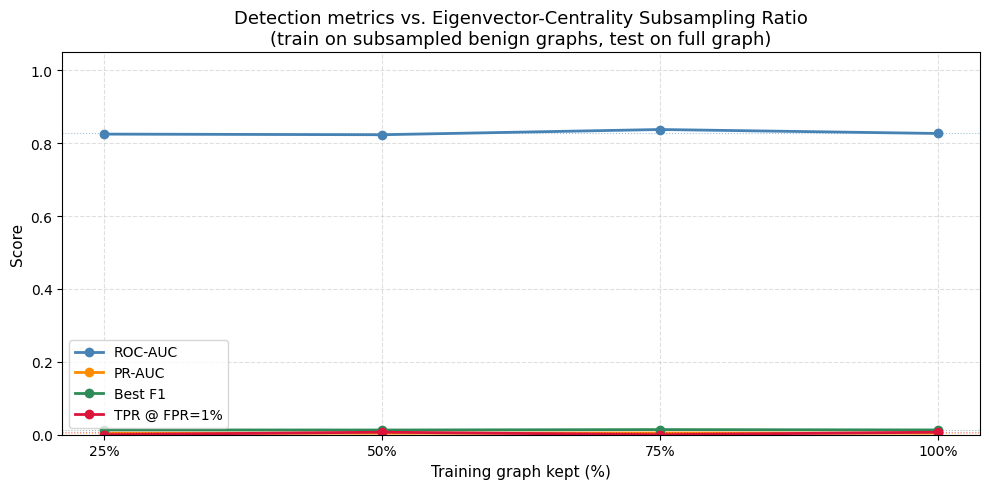

In [5]:
# ── Figure 1: All four metrics vs subsampling ratio ──────────────────────────
METRIC_KEYS    = ["auc", "pr_auc", "f1", "tpr_at_1fpr"]
METRIC_LABELS  = ["ROC-AUC", "PR-AUC", "Best F1", "TPR @ FPR=1%"]
COLORS         = ["steelblue", "darkorange", "seagreen", "crimson"]

fig, ax = plt.subplots(figsize=(10, 5))

for key, lbl, color in zip(METRIC_KEYS, METRIC_LABELS, COLORS):
    vals = [m[key] for m in results]
    ax.plot(RATIOS, vals, marker='o', linewidth=2, color=color, label=lbl)
    # Annotate baseline (100 %)
    ax.axhline(vals[-1], color=color, linestyle=':', linewidth=0.8, alpha=0.5)

ax.set_title("Detection metrics vs. Eigenvector-Centrality Subsampling Ratio\n"
             "(train on subsampled benign graphs, test on full graph)", fontsize=13)
ax.set_xlabel("Training graph kept (%)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_xticks(RATIOS)
ax.set_xticklabels([f"{r}%" for r in RATIOS])
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("metrics_vs_subsampling.png", dpi=150)
plt.show()


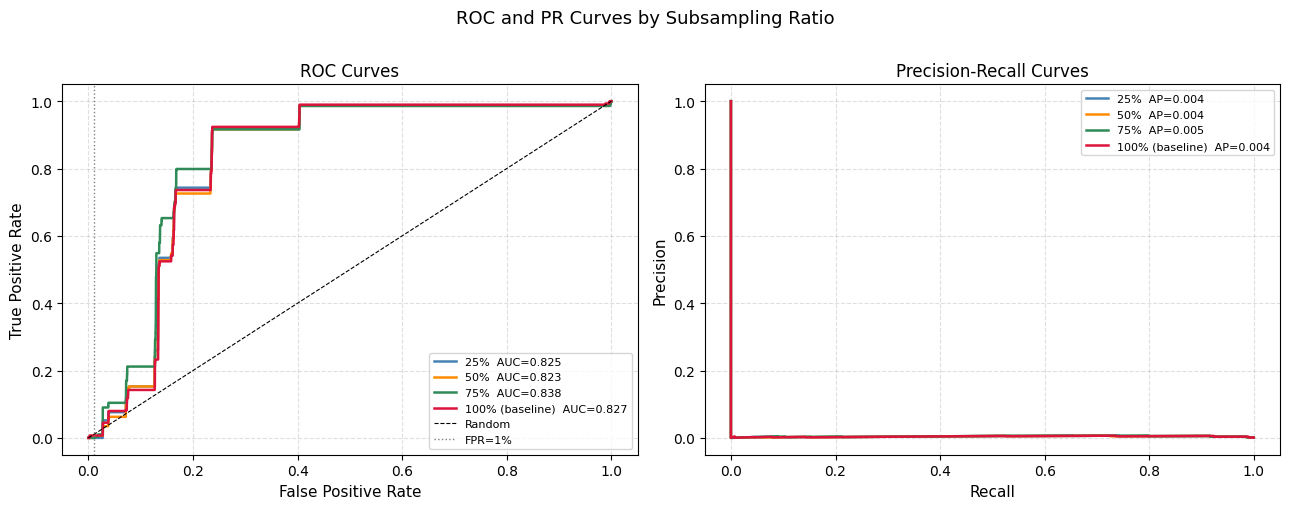

In [6]:
# ── Figure 2: ROC curves overlay + PR curves overlay ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ratio_labels = [f"{r}%" if r < 100 else "100% (baseline)" for r in RATIOS]

for m, lbl, color in zip(results, ratio_labels, COLORS):
    if not m["fpr_curve"]:
        continue
    # ROC
    axes[0].plot(m["fpr_curve"], m["tpr_curve"],
                 linewidth=1.8, color=color, label=f"{lbl}  AUC={m['auc']:.3f}")
    # PR
    axes[1].plot(m["recall_curve"], m["precision_curve"],
                 linewidth=1.8, color=color, label=f"{lbl}  AP={m['pr_auc']:.3f}")

# ROC panel
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
axes[0].axvline(0.01, color="gray", linestyle=":", linewidth=1, label="FPR=1%")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("ROC Curves", fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle="--", alpha=0.4)

# PR panel
axes[1].set_xlabel("Recall", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curves", fontsize=12)
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("ROC and PR Curves by Subsampling Ratio", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


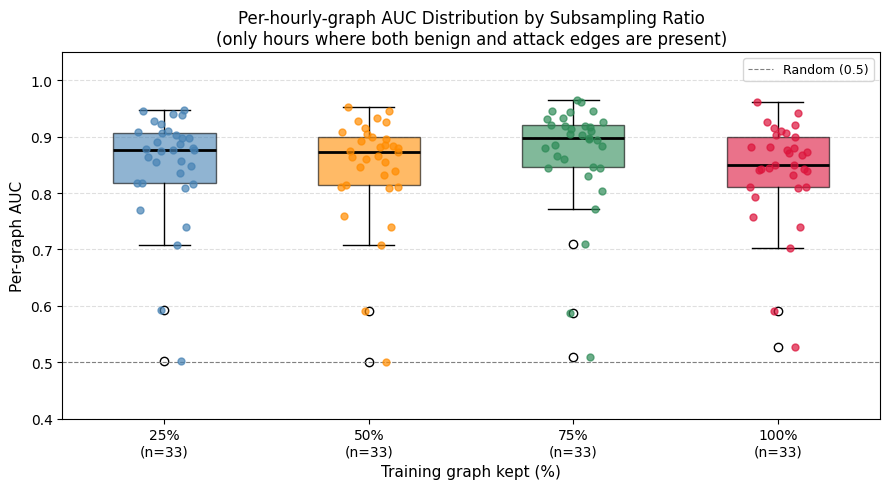


 Ratio   Mean AUC     Std     Min     Max   n graphs
--------------------------------------------------
   25%     0.8498  0.0957  0.5019  0.9469         33
   50%     0.8450  0.0950  0.5003  0.9535         33
   75%     0.8687  0.0979  0.5092  0.9645         33
  100%     0.8395  0.0908  0.5269  0.9612         33


In [7]:
# ── Figure 3: Per-graph AUC distribution (boxplot) ───────────────────────────
per_graph_data = [m["per_graph_aucs"] for m in results]
n_graphs       = [len(d) for d in per_graph_data]

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    [d if d else [np.nan] for d in per_graph_data],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    widths=0.5,
)

for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay individual points (jittered)
for i, (data_points, color) in enumerate(zip(per_graph_data, COLORS), start=1):
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(data_points))
    ax.scatter(np.full(len(data_points), i) + jitter, data_points,
               color=color, alpha=0.7, s=25, zorder=3)

ax.set_xticks(range(1, len(RATIOS) + 1))
ax.set_xticklabels([f"{r}%\n(n={n})" for r, n in zip(RATIOS, n_graphs)], fontsize=10)
ax.set_xlabel("Training graph kept (%)", fontsize=11)
ax.set_ylabel("Per-graph AUC", fontsize=11)
ax.set_title("Per-hourly-graph AUC Distribution by Subsampling Ratio\n"
             "(only hours where both benign and attack edges are present)", fontsize=12)
ax.set_ylim(0.4, 1.05)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Random (0.5)")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("per_graph_auc_boxplot.png", dpi=150)
plt.show()

# Summary statistics per ratio
print(f"\n{'Ratio':>6}  {'Mean AUC':>9}  {'Std':>6}  {'Min':>6}  {'Max':>6}  {'n graphs':>9}")
print("-" * 50)
for ratio, data_points in zip(RATIOS, per_graph_data):
    if data_points:
        print(f"{ratio:>5}%  {np.mean(data_points):>9.4f}  {np.std(data_points):>6.4f}  "
              f"{np.min(data_points):>6.4f}  {np.max(data_points):>6.4f}  {len(data_points):>9}")
    else:
        print(f"{ratio:>5}%  {'N/A':>9}")
